PONTIFÍCIA UNIVERSIDADE CATÓLICA DE MINAS GERAIS\
PROFESSOR: LEANDRO FIGUEIRA LESSA\
INTEGRANTES DO GRUPO: Charlene Aparecida Salustiano de Jesus, Edimilson Estevam da Cruz, Lucas Cinquenti Moreira, Michele Mayumi Miyazaki\
DISCIPLINA: PYTHON PARA CIÊNCIA DE DADOS\
ATIVIDADE: ANÁLISE DO DESENVOLVIMENTO HUMANO E ECONÔMICO GLOBAL

INSTALANDO BIBLITECAS


In [1]:
!pip install -r ../requirements.txt

In [2]:
!pip install ipeadatapy geopandas matplotlib



IMPORTAÇÃO DAS BIBLIOTECAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipeadatapy as ipea

DEFINIÇÃO DAS VARIÁVEIS

In [36]:
arquivoprincipal = 'gapminder_full.csv'
arquivoprincipalTratado = 'gapminder_tratados.csv'
arquivoidh91 = 'idh1991.csv'
arquivoidh00 = 'idh1991.csv'
arquivopib = 'ipeadata_pib.csv'

LEITURA DO ARQUIVO .CSV - Análise do Desenvolvimento Humano e Econômico Global com Base no Dataset 
Gapminder


In [3]:
df_principal = pd.read_csv('../data/raw/'+arquivoprincipal, sep=',')


EXIBINDO UMA AMOSTRA DOS DADOS

In [5]:
df_principal.head(5)

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


EXIBINDO OS METADADOS (SCHEMA) DO ARQUIVO

In [6]:
df_principal.info()

<class 'pandas.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1736 non-null   str    
 1   year       1736 non-null   int64  
 2   pop        1736 non-null   float64
 3   continent  1736 non-null   str    
 4   lifeExp    1736 non-null   float64
 5   gdpPercap  1736 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 81.5 KB


In [7]:
df_principal.describe().round(2)

,year,pop,lifeExp,gdpPercap
count,1736.00,1.736000e+03,1736.00,1736.00
mean,1979.67,3.156800e+07,59.51,7240.16
std,17.30,1.172888e+08,12.96,9839.87
min,1952.00,6.001100e+04,23.60,241.17
25%,1967.00,2.818694e+06,48.24,1202.06
50%,1982.00,7.150606e+06,60.81,3534.77
75%,1997.00,1.977102e+07,70.94,9380.25
max,2007.00,1.318683e+09,82.60,113523.13


In [8]:
df_principal['lifeExp'].describe().round(2)

count    1736.00
mean       59.51
std        12.96
min        23.60
25%        48.24
50%        60.81
75%        70.94
max        82.60
Name: lifeExp, dtype: float64

In [9]:
df_principal.get('continent').value_counts()

continent
Africa      633
Asia        401
Europe      370
Americas    308
Oceania      24
Name: count, dtype: int64

In [10]:
df_principal.duplicated().sum()

np.int64(32)

In [11]:
filtro = df_principal.duplicated()
df_principal[filtro]

,country,year,pop,continent,lifeExp,gdpPercap
72,Afghanistan,1997,2.222742e+07,Asia,41.763,635.341351
145,Bolivia,1987,6.156369e+06,Americas,57.251,2753.691490
146,Bolivia,1992,6.893451e+06,Americas,59.957,2961.699694
147,Bolivia,1997,7.693188e+06,Americas,62.050,3326.143191
148,Bolivia,2002,8.445134e+06,Americas,63.883,3413.262690
149,Bolivia,2007,9.119152e+06,Americas,65.554,3822.137084
161,Belgium,2007,1.039223e+07,Europe,79.441,33692.605080
207,Burkina Faso,1987,7.586551e+06,Africa,49.557,912.063142
232,Cambodia,1987,8.371791e+06,Asia,53.914,683.895573
345,China,1997,1.230075e+09,Asia,70.426,2289.234136


In [12]:
df_principal = df_principal.drop_duplicates()

In [13]:
df_principal.duplicated().sum()

np.int64(0)

DADOS AUSENTES

In [14]:
df_principal.isna().sum()

country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64

PARA SALVAR O ARQUIVO TRATADO

In [17]:
df_principal.to_csv('../data/processed/gapminder_tratados.csv', sep=',', index=False, encoding='UTF-8')

PARA LER O ARQUIVO TRATADO

In [38]:
df_principalTratado = pd.read_csv('../data/processed/'+arquivoprincipalTratado, sep=',')

------------------------------------------------------------------------------------------
Função para os cálculos de Renda Per Capita
------------------------------------------------------------------------------------------

Lista dos países e a renda média per capita correspondente
         country  gdpPercap
0         Kuwait   65332.91
1    Switzerland   27074.33
2         Norway   26747.31
3  United States   26261.15
4         Canada   22410.75 

Descrição do conjunto de dados
       gdpPercap
count       5.00
mean    33565.29
std     17857.59
min     22410.75
25%     26261.15
50%     26747.31
75%     27074.33
max     65332.91 

Estrutura dos dados
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    5 non-null      str    
 1   gdpPercap  5 non-null      float64
dtypes: float64(1), str(1)
memory usage: 212.0 bytes


 GRÁFICO 1


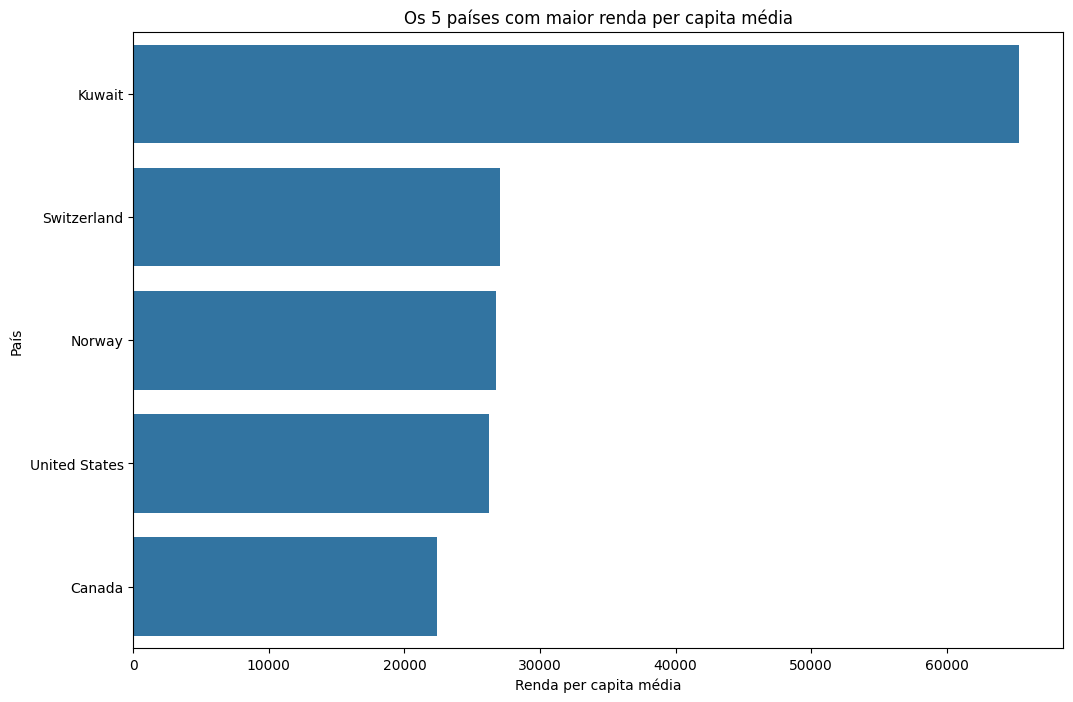

In [55]:
# Criando a função
def CalculaRendaPais (df_principalTratado):
    resultado = (
        df_principalTratado.groupby('country')['gdpPercap']
        .mean()
        .sort_values(ascending=False) #indicador que apresentará os países maiores PIBs
        .head(5)        
        .reset_index()

    )
    return resultado  

#Para definir o resultado
df_resultado = CalculaRendaPais(df_principalTratado)

#Para mostrar o head, describe e info
print ('Lista dos países e a renda média per capita correspondente')
print(df_resultado.head().round(2),'\n')

print ('Descrição do conjunto de dados')
print(df_resultado.describe().round(2), '\n')

print ('Estrutura dos dados')
df_resultado.info()

print ('\n\n GRÁFICO 1')

#Para configurar o gráfico
plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_resultado,
    x='gdpPercap',
    y='country'
)

plt.title("Os 5 países com maior renda per capita média")
plt.xlabel("Renda per capita média")
plt.ylabel("País")

plt.show()



Lista dos países e a renda média per capita correspondente
      country  gdpPercap
0     Myanmar     439.33
1     Burundi     471.66
2    Ethiopia     509.12
3     Eritrea     541.00
4  Mozambique     542.28 

Descrição do conjunto de dados
       gdpPercap
count       5.00
mean      500.68
std        44.81
min       439.33
25%       471.66
50%       509.12
75%       541.00
max       542.28 

Estrutura dos dados
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    5 non-null      str    
 1   gdpPercap  5 non-null      float64
dtypes: float64(1), str(1)
memory usage: 212.0 bytes


 GRÁFICO 2


C:\Users\charl\AppData\Local\Temp\ipykernel_39132\3081524882.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


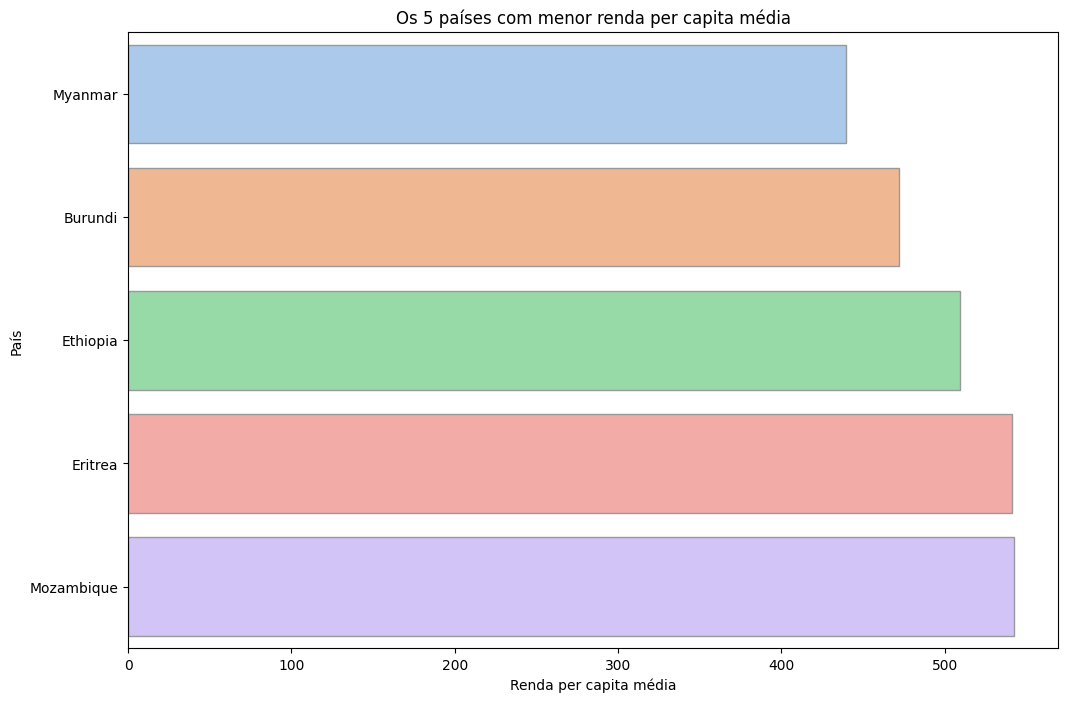

In [72]:
# Criando a função
def CalculaRendaPais (df_principalTratado):
    resultado = (
        df_principalTratado.groupby('country')['gdpPercap']
        .mean()
        .sort_values(ascending=True) #indicador que apresentará os países maiores PIBs
        .head(5)        
        .reset_index()

    )
    return resultado  

#Para definir o resultado
df_resultado = CalculaRendaPais(df_principalTratado)

#Para mostrar o head, describe e info
print ('Lista dos países e a renda média per capita correspondente')
print(df_resultado.head().round(2),'\n')

print ('Descrição do conjunto de dados')
print(df_resultado.describe().round(2), '\n')

print ('Estrutura dos dados')
df_resultado.info()

print ('\n\n GRÁFICO 2')

#Para configurar o gráfico
plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_resultado,
    x='gdpPercap',
    y='country',
    palette="pastel", edgecolor=".6",
    
)


plt.title("Os 5 países com menor renda per capita média")
plt.xlabel("Renda per capita média")
plt.ylabel("País")

plt.show()



Continentes e a renda média per capita correspondente
  continent  gdpPercap
0    Africa    2193.75
1  Americas    7136.11
2      Asia    7902.15
3    Europe   14469.48
4   Oceania   18621.61 

Descrição do conjunto de dados
       gdpPercap
count       5.00
mean    10064.62
std      6477.42
min      2193.75
25%      7136.11
50%      7902.15
75%     14469.48
max     18621.61 

Estrutura dos dados
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   continent  5 non-null      str    
 1   gdpPercap  5 non-null      float64
dtypes: float64(1), str(1)
memory usage: 212.0 bytes


 GRÁFICO 3


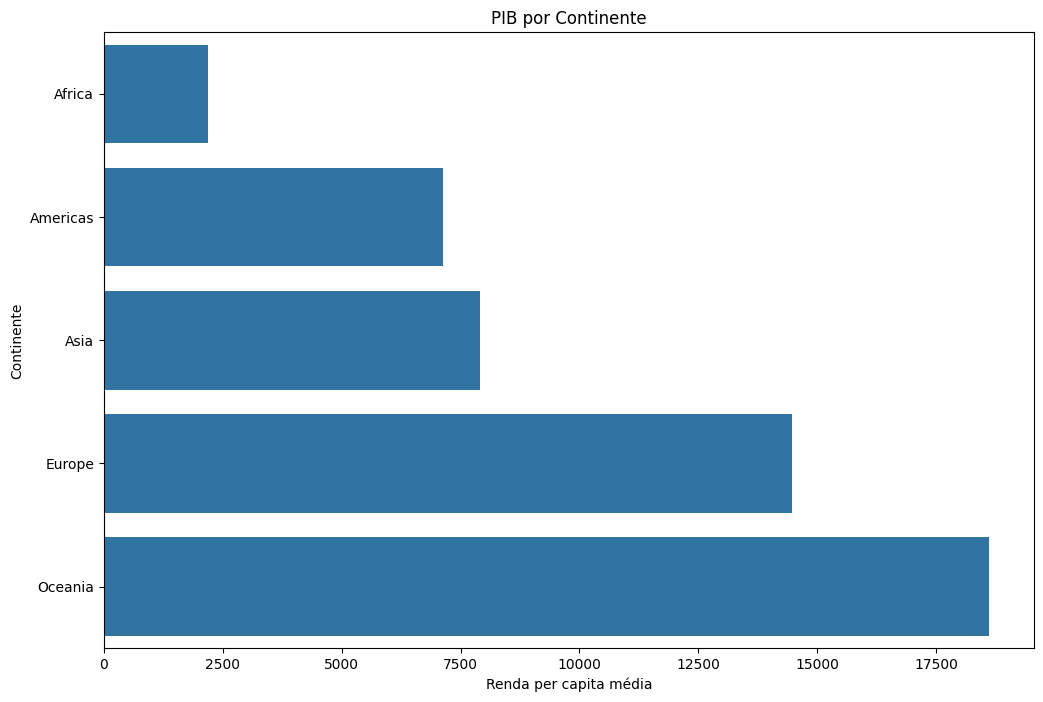

In [58]:
# Criando a função
def CalculaRendaContinente (df_principalTratado):
    resultado = (
        df_principalTratado.groupby('continent')['gdpPercap']
        .mean()
        .sort_values(ascending=True) #indicador que apresentará os PIBs dos Continentes
        .head(5)        
        .reset_index()

    )
    return resultado  

#Para definir o resultado
df_resultado = CalculaRendaContinente(df_principalTratado)

#Para mostrar o head, describe e info
print ('Continentes e a renda média per capita correspondente')
print(df_resultado.head().round(2),'\n')

print ('Descrição do conjunto de dados')
print(df_resultado.describe().round(2), '\n')

print ('Estrutura dos dados')
df_resultado.info()

print ('\n\n GRÁFICO 3')

#Para configurar o gráfico
plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_resultado,
    x='gdpPercap',
    y='continent'
)

plt.title("PIB por Continente")
plt.xlabel("Renda per capita média")
plt.ylabel("Continente")

plt.show()



PAREI AQUI
________________________________________________________________________

QUESTIONAMENTOS PARA A ANÁLISE SOBRE O PROGRESSO E AS DESIGUALDADES GLOBAIS\
Utilizar gráficos e mapas para destacar avanços significativos e também persistências de desigualdades sociais e 
econômicas. 

- País com maior renda per capita
- País com maior expectativa de vida
- Continente com maior expectativa de vida
- Continente com maior renda per capita
- País da Oceania com maior renda per capita
- País da Oceania com maior expectativa de vida
- País da Europa com maior renda per capita
- País da Europa com maior expectativa de vida
- País da Ásia com maior renda per capita
- País da Ásia com maior expectativa de vida
- País das Américas com maior renda per capita
- País das Américas com maior expectativa de vida
- País da África com maior renda per capita
- País da África com maior expectativa de vida
- Qual ano a expectativa de vida passou dos 60 anos no mundo?
- País com maior população nas Américas
- País com maior população na África
- País com maior população na Ásia
- País com maior população na Oceania
- País com maior população na Europa
- Se dividir o continente americano, qual das américas possui maior renda?
- Se dividir o continente americano, qual das américas possui maior expectativa de vida?

- Destacando o Brasil, qual o estado com maior renda per capita?
- Destacando o Brasil, qual o estado com maior expectativa de vida?

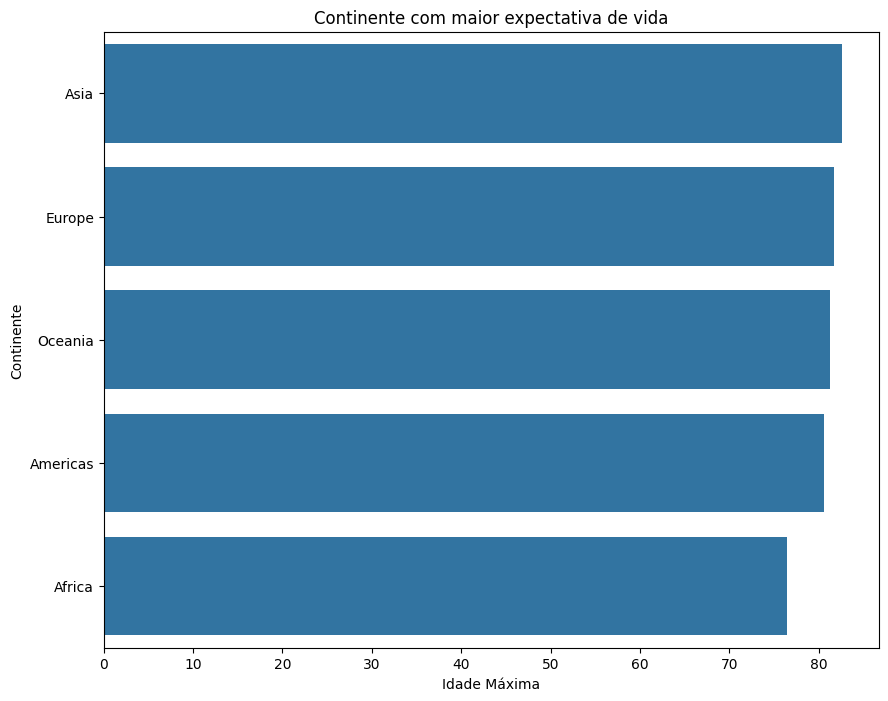

In [39]:
idh_continent = (
    df_principalTratado.groupby("continent")["lifeExp"]
    .max()
    .sort_values(ascending=False)
    .head()
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=idh_continent.values,
    y=idh_continent.index
)

plt.title("Continente com maior expectativa de vida")
plt.xlabel("Idade Máxima")
plt.ylabel("Continente")

plt.show()



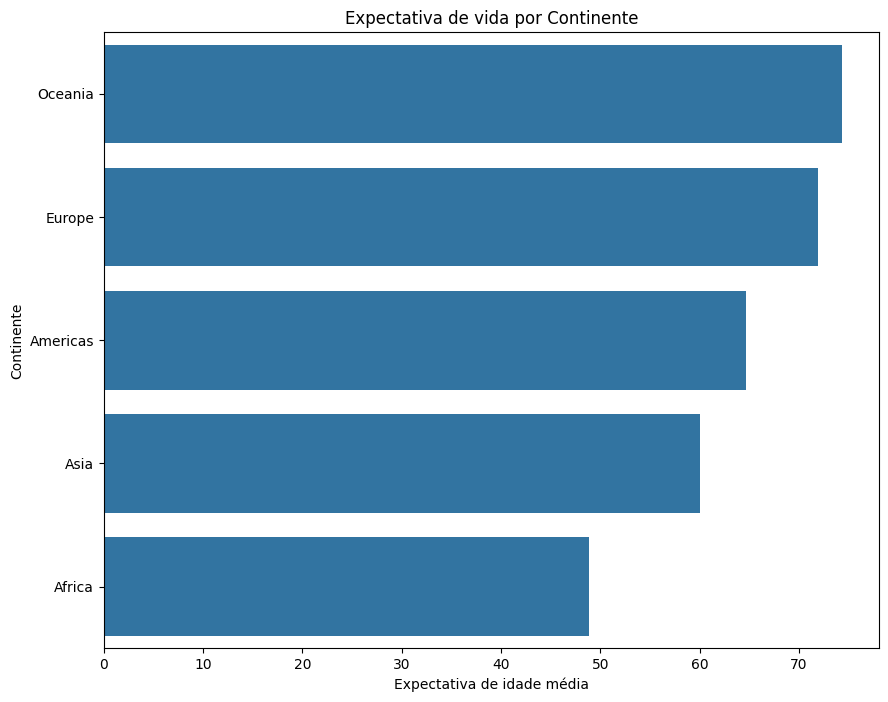

In [40]:
idh_continent = (
    df_principalTratado.groupby("continent")["lifeExp"]
    .mean()
    .sort_values(ascending=False)
    .head()
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=idh_continent.values,
    y=idh_continent.index
)

plt.title("Expectativa de vida por Continente")
plt.xlabel("Expectativa de idade média")
plt.ylabel("Continente")

plt.show()



In [ ]:
def CalculaExpectativaVidaPais (df_principal):
    resultado = (
    df_principal.loc(['country', 'lifeExp'].idxMax())
    .mean()
    .sort_values(by='lifeExp', ascending=True)
    .head()

    )
    return resultado  

In [ ]:
def CalculaExpectativaVidaContinente (df_principal):
    resultado = (
    df_principal.loc(['continent', 'lifeExp'].idxMax())
    .mean()
    .sort_values(by='lifeExp', ascending=True)
    .head()

    )
    return resultado  

In [ ]:
def CalculaPopulacaoContinente (df_principal):
    resultado = (
    df_principal.loc(['continent', 'pop'].idxMax())
    .mean()
    .sort_values(by='pop', ascending=True)
    .head()

    )
    return resultado  

In [ ]:
def CalculaPopulacaoPais (df_principal):
    resultado = (
    df_principal.loc(['country', 'pop'].idxMax())
    .mean()
    .sort_values(by='pop', ascending=True)
    .head()

    )
    return resultado  

País com maior renda per capita 

- Qual continente possui maior expectativa de vida?

In [21]:
df_principal.loc[df_principal['lifeExp'].idxmax()]



country            Japan
year                2007
pop          127467972.0
continent           Asia
lifeExp           82.603
gdpPercap    31656.06806
Name: 835, dtype: object

GRÁFICO

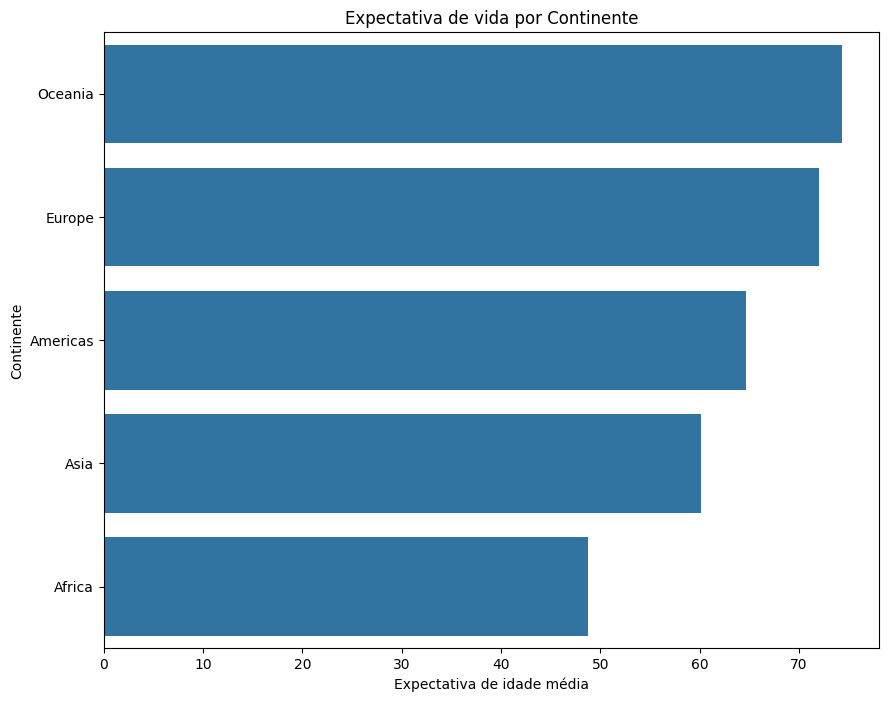

In [10]:
idh_continent = (
    df_principal.groupby("continent")["lifeExp"]
    .mean()
    .sort_values(ascending=False)
    .head()
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=idh_continent.values,
    y=idh_continent.index
)

plt.title("Expectativa de vida por Continente")
plt.xlabel("Expectativa de idade média")
plt.ylabel("Continente")

plt.show()

- Qual a maior renda per capita entre os continentes?

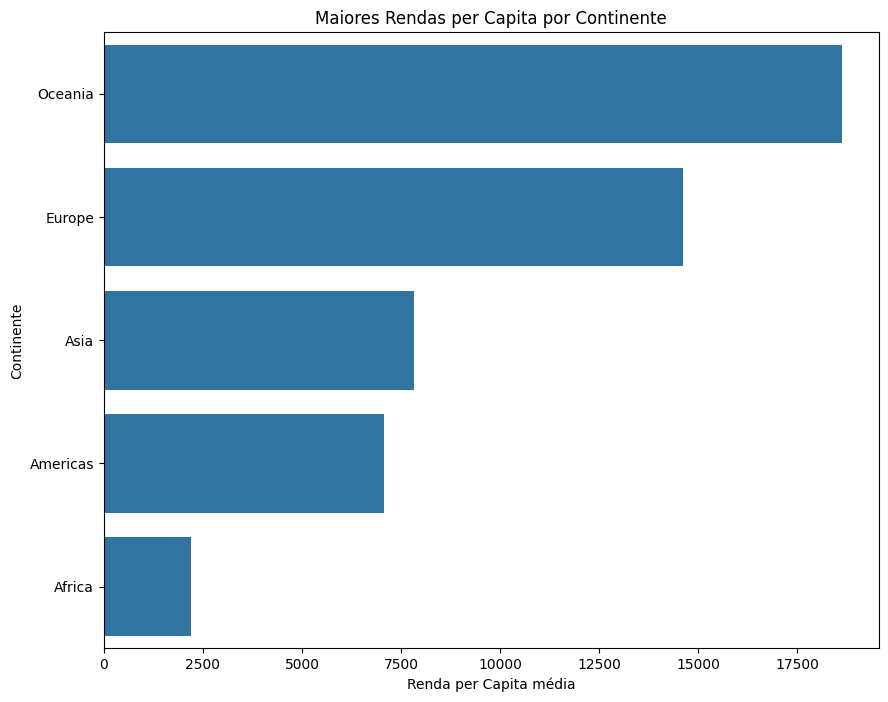

In [20]:
idh_continent = (
    df.groupby("continent")["gdpPercap"]
    .mean()
    .sort_values(ascending=False)
    .head()
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=idh_continent.values,
    y=idh_continent.index
)

plt.title("Maiores Rendas per Capita por Continente")
plt.xlabel("Renda per Capita média")
plt.ylabel("Continente")

plt.show()

PARA ANÁLISE DE DADOS IPEADATA

In [19]:
df = pd.read_csv('../data/raw/'+arquivoidh, sep=';', encoding='utf-8')

In [20]:
df.head()

,Territorialidade,Posição IDHM,IDHM,Posição IDHM Renda,IDHM Renda,Posição IDHM Educação,IDHM Educação,Posição IDHM Longevidade,IDHM Longevidade,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,Distrito Federal,1,"0,616",1,"0,762",1,"0,419",2,"0,731",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,São Paulo,2,"0,578",2,"0,729",3,"0,363",3,"0,73",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Rio de Janeiro,3,"0,573",3,"0,696",2,"0,392",6,"0,69",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Santa Catarina,4,"0,543",5,"0,648",4,"0,329",1,"0,753",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Rio Grande do Sul,5,"0,542",4,"0,667",5,"0,328",4,"0,729",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df.describe()

,Posição IDHM,Posição IDHM Renda,Posição IDHM Educação,Posição IDHM Longevidade,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,27.000000,27.000000,27.000000,27.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,14.000000,14.000000,13.925926,13.925926,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7.937254,7.937254,7.927197,7.956255,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.500000,7.500000,7.500000,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,14.000000,14.000000,14.000000,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,20.500000,20.500000,20.500000,20.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,27.000000,27.000000,27.000000,27.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


CONCLUSÃO
